Accelerations shape: (100, 10001)
Mean modal mass ratios shape: (100,)
Overall mean modal mass ratio = 0.0566018112475426
Overall std modal mass ratio  = 0.0022271941622490628


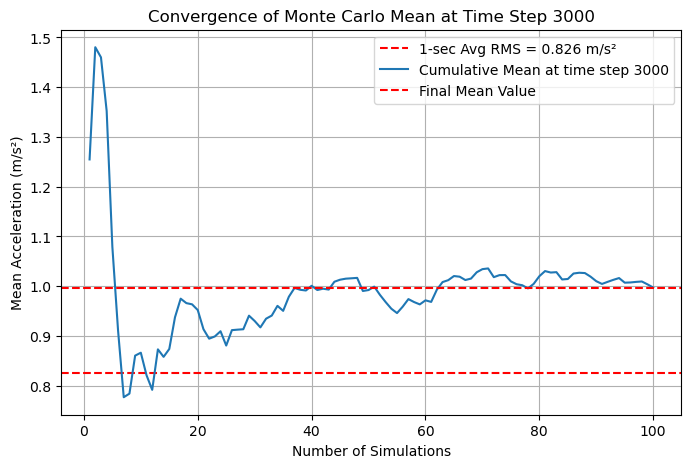

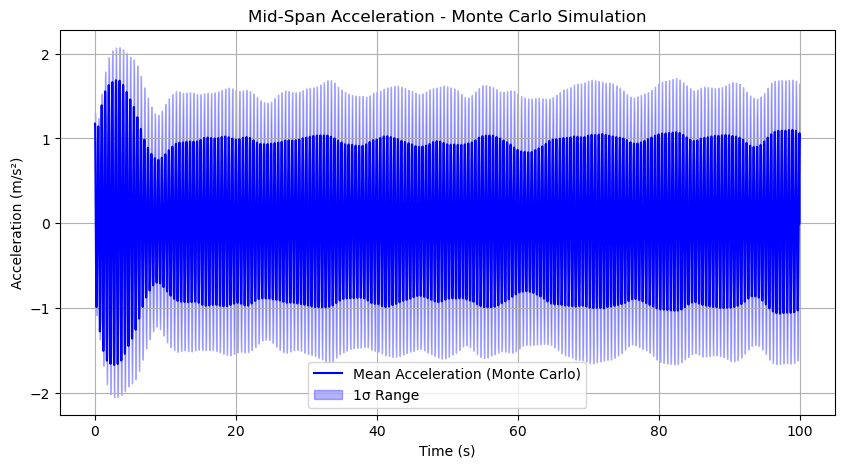

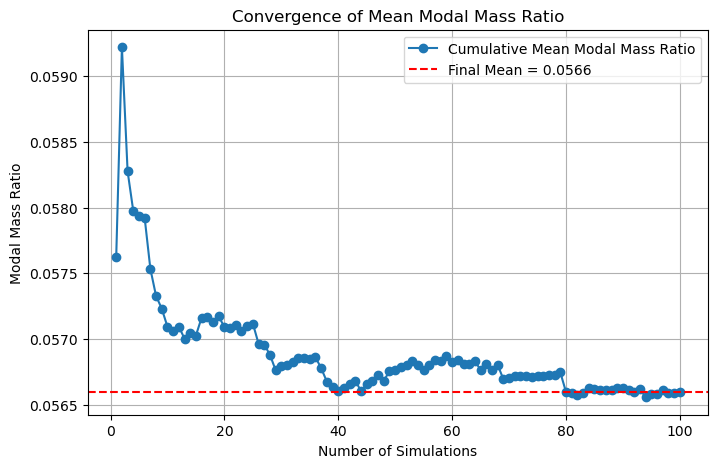

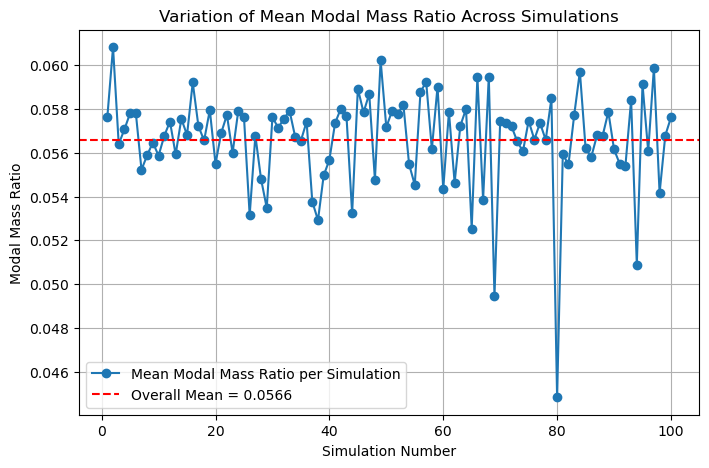

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import multiprocessing 
import numpy as np
import torch
import socialforce
import matplotlib.pyplot as plt
from socialforcefunctions import initial_state_corridor
from solver import Newmarksuper_HSIsocial, compute_1sec_rms_mean
from matrix import bridge
from pedestrian import Pedestrian
from reliability import run_simulation

# Define Monte Carlo settings
NUM_SIMULATIONS = 100  # Number of Monte Carlo runs (increase for better statistics)
NUM_PROCESSES = 10  # Use all available CPU cores
hht = 0.01

# Using multiprocessing Pool to parallelize the simulations
if __name__ == "__main__":
    with multiprocessing.Pool(processes=NUM_PROCESSES) as pool:
        peddamp = 0.30
        pedBodyF = 3.10
        Tocity = 10
        Outcity = 10
        Length = 50
        Width = 2
        args_list = [(None, peddamp, pedBodyF,Tocity, Outcity, Length, Width) for _ in range(NUM_SIMULATIONS)]
        results = pool.map(run_simulation, args_list)

    # Convert results to NumPy array for statistical processing
    accelerations = [r[0] for r in results]
    mean_mass_ratios = [r[1] for r in results]

    # Convert to NumPy arrays
    accelerations = np.array(accelerations)         # shape: (num_sims, n_time_steps)
    mean_mass_ratios = np.array(mean_mass_ratios)   # shape: (num_sims,)

    print("Accelerations shape:", accelerations.shape)
    print("Mean modal mass ratios shape:", mean_mass_ratios.shape)

 # --------------------------------------------------
    # Acceleration statistics
    # --------------------------------------------------
    mean_acceleration = np.mean(accelerations, axis=0)
    std_acceleration = np.std(accelerations, axis=0)

    # --------------------------------------------------
    # Cumulative mean of acceleration
    # --------------------------------------------------
    cumulative_means = np.array([
        np.mean(accelerations[:i+1], axis=0) for i in range(NUM_SIMULATIONS)
    ])

    # Pick a specific time step to check convergence
    time_step = 3000
    convergence_curve = cumulative_means[:, time_step]

    # Compute 1-second average RMS
    avg_1sec_rms = compute_1sec_rms_mean(accelerations, int(1 / hht))

    # Time vector
    t = np.arange(accelerations.shape[1]) * hht

    # --------------------------------------------------
    # Modal mass ratio statistics
    # --------------------------------------------------
    overall_mean_mass_ratio = np.mean(mean_mass_ratios)
    overall_std_mass_ratio = np.std(mean_mass_ratios)

    # Cumulative mean modal mass ratio
    sim_numbers = np.arange(1, NUM_SIMULATIONS + 1)
    cumulative_mean_mass_ratio = np.cumsum(mean_mass_ratios) / sim_numbers

    print("Overall mean modal mass ratio =", overall_mean_mass_ratio)
    print("Overall std modal mass ratio  =", overall_std_mass_ratio)

    # --------------------------------------------------
    # Plot 1: Acceleration convergence at selected time step
    # --------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.axhline(avg_1sec_rms, color='red', linestyle='--',
                label=f'1-sec Avg RMS = {avg_1sec_rms:.3f} m/s²')
    plt.plot(sim_numbers, convergence_curve, label=f"Cumulative Mean at time step {time_step}")
    plt.axhline(y=convergence_curve[-1], color='r', linestyle="--", label="Final Mean Value")
    plt.xlabel("Number of Simulations")
    plt.ylabel("Mean Acceleration (m/s²)")
    plt.title(f"Convergence of Monte Carlo Mean at Time Step {time_step}")
    plt.legend()
    plt.grid()
    plt.show()

    # --------------------------------------------------
    # Plot 2: Mean acceleration time history
    # --------------------------------------------------
    plt.figure(figsize=(10, 5))
    plt.plot(t, mean_acceleration, label="Mean Acceleration (Monte Carlo)", color='b')
    plt.fill_between(
        t,
        mean_acceleration - std_acceleration,
        mean_acceleration + std_acceleration,
        color='b',
        alpha=0.3,
        label="1σ Range"
    )
    plt.title("Mid-Span Acceleration - Monte Carlo Simulation")
    plt.xlabel("Time (s)")
    plt.ylabel("Acceleration (m/s²)")
    plt.legend()
    plt.grid()
    plt.show()

    # --------------------------------------------------
    # Plot 3: Cumulative mean of modal mass ratio
    # --------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(sim_numbers, cumulative_mean_mass_ratio, marker='o',
             label="Cumulative Mean Modal Mass Ratio")
    plt.axhline(overall_mean_mass_ratio, color='r', linestyle='--',
                label=f"Final Mean = {overall_mean_mass_ratio:.4f}")
    plt.xlabel("Number of Simulations")
    plt.ylabel("Modal Mass Ratio")
    plt.title("Convergence of Mean Modal Mass Ratio")
    plt.legend()
    plt.grid()
    plt.show()

    # --------------------------------------------------
    # Plot 4: Variation of modal mass ratio across simulations
    # --------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(sim_numbers, mean_mass_ratios, marker='o', linestyle='-',
             label="Mean Modal Mass Ratio per Simulation")
    plt.axhline(overall_mean_mass_ratio, color='r', linestyle='--',
                label=f"Overall Mean = {overall_mean_mass_ratio:.4f}")
    plt.xlabel("Simulation Number")
    plt.ylabel("Modal Mass Ratio")
    plt.title("Variation of Mean Modal Mass Ratio Across Simulations")
    plt.legend()
    plt.grid()
    plt.show()

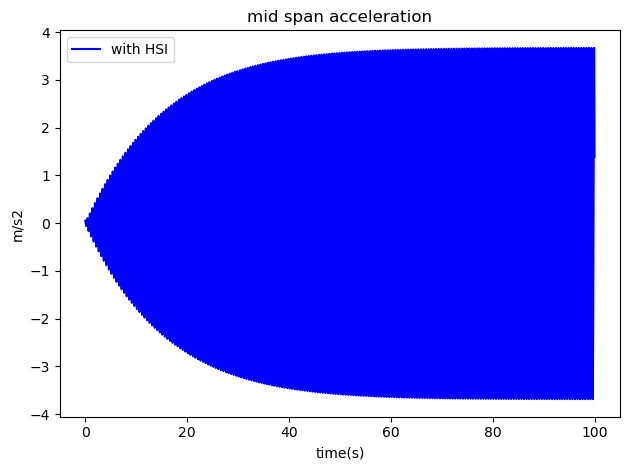

In [2]:
from matrix import*  
from solver import *
from pedestrian import* 
from matplotlib import pyplot as plt
import math
import numpy as np


#step 1 setup beam and pedestrians
#beam
numElements = 10  # n - Number of beam elements !not for modal
length = 50  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq = np.array([2,8])  #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2



numbers = 2 #modes bein considered
#modal_mass = 58000 #kg
#def curve1(x):
#    return -3.3245e-23 * x**0 + -1.4885e-02 * x**1 + 7.2714e-04 * x**2 + 1.2637e-04 * x**3 + -1.4437e-05 * x**4 + 7.2750e-07 * x**5 + -1.9644e-08 * x**6 + 3.0059e-10 * x**7 + -2.6205e-12 * x**8 + 1.2166e-14 * x**9 + -2.3396e-17 * x**10 + 9.6919e-29 * x**11

ModalMass = 1.28*linearMass*length/2


def curve1(x):
    return np.sin(np.pi*x/length)

def curve2(x):
    return np.sin(2*np.pi*x/length)

hht = 0.01
t_end = 100 
func_list=[curve1,curve2] 
modalmass = [ModalMass,ModalMass]
modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12


Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = numbers,
    freq = beamFreq,
      )                   #modes


         
density = 0.2

t, u, du, ddu = Newmarksuper_Code(
    Bridge,
    numbers,
    length,
    hht,
    t_end,
    width,
    beamFreq,        # walking frequency fs
    density,            # density ped/m²
    modalDampingRatio,
    density*length*width,
    length * width, # deck area S
    modalmass,
    func_list
)
accn_hsi = accdyn_super_social(Bridge,ddu ,x_interested,modalmass,func_list)
#vertical_displacement = accdyn_super(Bridge,u,25,hht)


plt.plot(t,accn_hsi,label ="with HSI",color='b')
plt.title("mid span acceleration")
plt.xlabel("time(s)")
plt.ylabel("m/s2")
plt.legend()
plt.tight_layout()
#plt.savefig("All In one", format='pdf', dpi=300)  
plt.show()
#print("ddu",ddu)
#print("accn",accn)'''

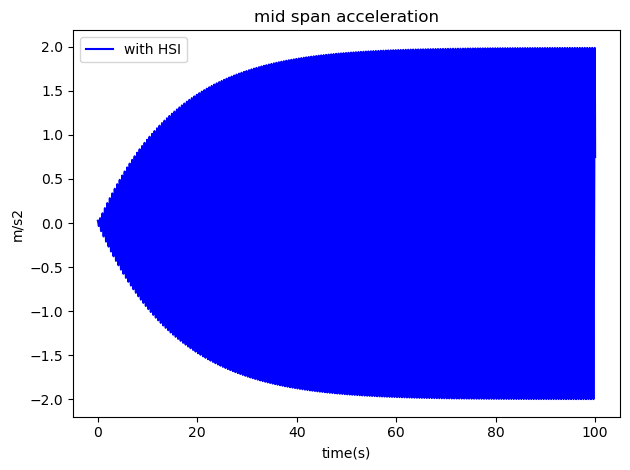

In [4]:
from matrix import*  
from solver import *
from pedestrian import* 
from matplotlib import pyplot as plt
import math
import numpy as np


#step 1 setup beam and pedestrians
#beam
numElements = 10  # n - Number of beam elements !not for modal
length = 50  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005# xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq = np.array([2.00,8])  #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2



numbers = 2 #modes bein considered
#modal_mass = 58000 #kg
#def curve1(x):
#    return -3.3245e-23 * x**0 + -1.4885e-02 * x**1 + 7.2714e-04 * x**2 + 1.2637e-04 * x**3 + -1.4437e-05 * x**4 + 7.2750e-07 * x**5 + -1.9644e-08 * x**6 + 3.0059e-10 * x**7 + -2.6205e-12 * x**8 + 1.2166e-14 * x**9 + -2.3396e-17 * x**10 + 9.6919e-29 * x**11

ModalMass = 1.28*linearMass*length/2 *1.15


def curve1(x):
    return np.sin(np.pi*x/length)

def curve2(x):
    return np.sin(2*np.pi*x/length)

hht = 0.01
t_end = 100 
func_list=[curve1,curve2] 
modalmass = [ModalMass,ModalMass]
modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12


Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = numbers,
    freq = beamFreq,
      )                   #modes


         
density = 0.2 * 0.388

t, u, du, ddu1 = Newmarksuper_Code(
    Bridge,
    numbers,
    length,
    hht,
    t_end,
    width,
    beamFreq,        # walking frequency fs
    density,            # density ped/m²
    modalDampingRatio,
    density*length*width,
    length * width, # deck area S
    modalmass,
    func_list
)
accn_hsi_simplified1 = accdyn_super_social(Bridge,ddu1 ,x_interested,modalmass,func_list)
#vertical_displacement = accdyn_super(Bridge,u,25,hht)


plt.plot(t,accn_hsi_simplified1,label ="with HSI",color='b')
plt.title("mid span acceleration")
plt.xlabel("time(s)")
plt.ylabel("m/s2")
plt.legend()
plt.tight_layout()
#plt.savefig("All In one", format='pdf', dpi=300)  
plt.show()
#print("ddu",ddu)
#print("accn",accn)'''

Code model 95th percentile        = 3.6104555813275305
Simplified model 95th percentile  = 1.9556000008188856
Surrogate 95th percentiles shape  = (100,)
Code model error shape            = (100,)
Simplified model error shape      = (100,)

--- Code model error statistics ---
Mean = 0.4678400071068454
Std  = 0.06301199176208086
5th  = 0.38043271328209194
50th = 0.45998448555665167
95th = 0.5817509846827217

--- Simplified model error statistics ---
Mean = 0.8637326468193514
Std  = 0.11633360464957317
5th  = 0.702360100436568
50th = 0.8492296750392022
95th = 1.0740366581668064


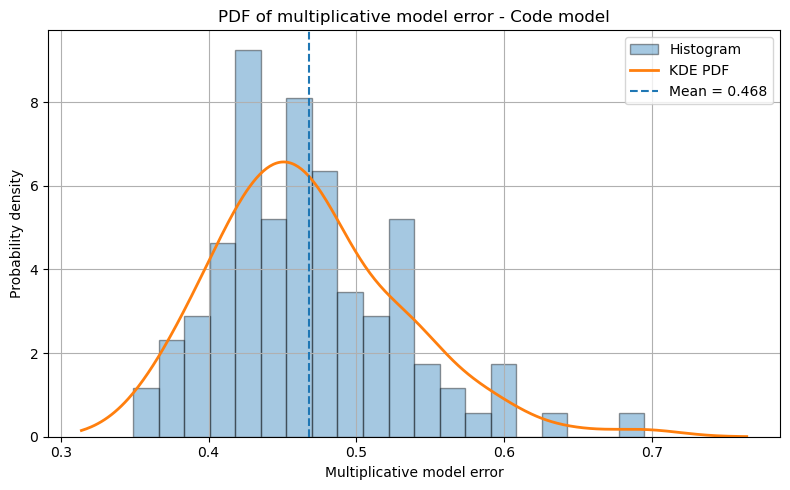

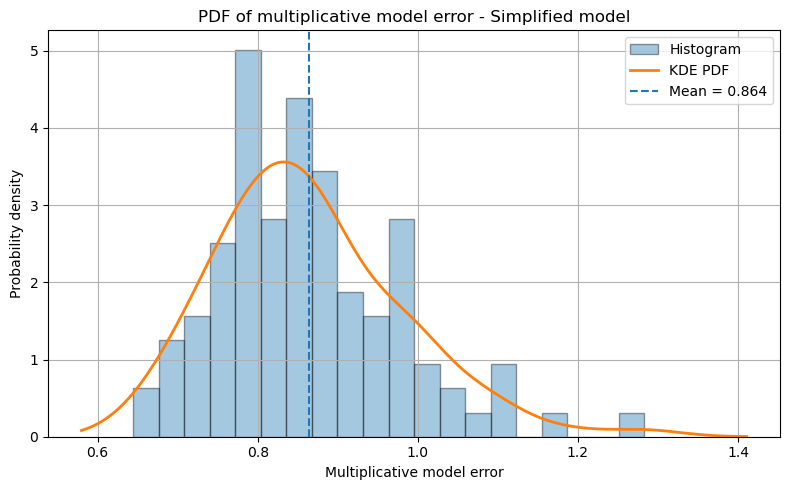

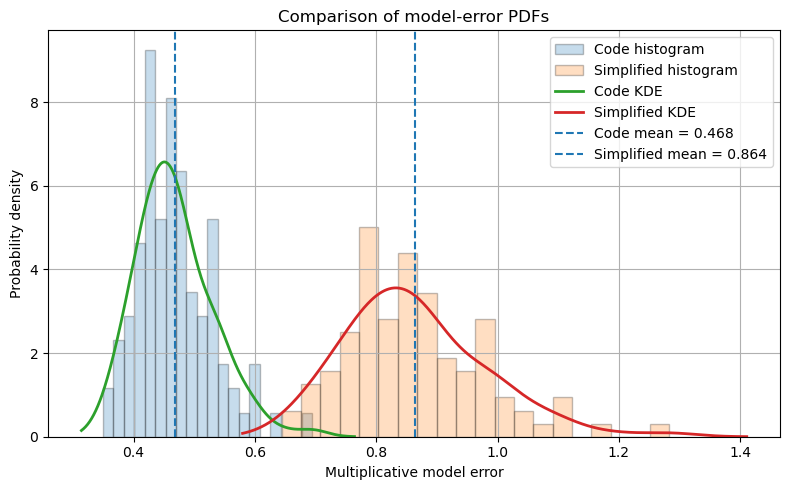

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# --------------------------------------------------
# 1) 95th percentile of each stochastic time history
#    one value per simulation
# --------------------------------------------------
surrogate_p95 = np.percentile(np.abs(accelerations), 95, axis=1)

# --------------------------------------------------
# 2) 95th percentile of deterministic model histories
# --------------------------------------------------
code_p95 = np.percentile(np.abs(accn_hsi), 95)
simplified_p95 = np.percentile(np.abs(accn_hsi_simplified1), 95)

if code_p95 <= 0:
    raise ValueError("Code-model 95th percentile is zero or negative.")
if simplified_p95 <= 0:
    raise ValueError("Simplified-model 95th percentile is zero or negative.")

# --------------------------------------------------
# 3) Multiplicative model error samples
#    Xm = surrogate / deterministic
# --------------------------------------------------
model_error_code = surrogate_p95 / code_p95
model_error_simplified = surrogate_p95 / simplified_p95

# --------------------------------------------------
# 4) Summary statistics
# --------------------------------------------------
print("Code model 95th percentile        =", code_p95)
print("Simplified model 95th percentile  =", simplified_p95)
print("Surrogate 95th percentiles shape  =", surrogate_p95.shape)
print("Code model error shape            =", model_error_code.shape)
print("Simplified model error shape      =", model_error_simplified.shape)

print("\n--- Code model error statistics ---")
print("Mean =", np.mean(model_error_code))
print("Std  =", np.std(model_error_code, ddof=1))
print("5th  =", np.percentile(model_error_code, 5))
print("50th =", np.percentile(model_error_code, 50))
print("95th =", np.percentile(model_error_code, 95))

print("\n--- Simplified model error statistics ---")
print("Mean =", np.mean(model_error_simplified))
print("Std  =", np.std(model_error_simplified, ddof=1))
print("5th  =", np.percentile(model_error_simplified, 5))
print("50th =", np.percentile(model_error_simplified, 50))
print("95th =", np.percentile(model_error_simplified, 95))

# --------------------------------------------------
# 5) KDE for code model error
# --------------------------------------------------
x_grid_code = np.linspace(
    model_error_code.min() * 0.9,
    model_error_code.max() * 1.1,
    400
)
kde_code = gaussian_kde(model_error_code)
pdf_code = kde_code(x_grid_code)

plt.figure(figsize=(8, 5))
plt.hist(model_error_code, bins=20, density=True, alpha=0.4,
         edgecolor='black', label='Histogram')
plt.plot(x_grid_code, pdf_code, linewidth=2, label='KDE PDF')
plt.axvline(np.mean(model_error_code), linestyle='--',
            label=f"Mean = {np.mean(model_error_code):.3f}")
plt.xlabel("Multiplicative model error")
plt.ylabel("Probability density")
plt.title("PDF of multiplicative model error - Code model")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 6) KDE for simplified model error
# --------------------------------------------------
x_grid_simplified = np.linspace(
    model_error_simplified.min() * 0.9,
    model_error_simplified.max() * 1.1,
    400
)
kde_simplified = gaussian_kde(model_error_simplified)
pdf_simplified = kde_simplified(x_grid_simplified)

plt.figure(figsize=(8, 5))
plt.hist(model_error_simplified, bins=20, density=True, alpha=0.4,
         edgecolor='black', label='Histogram')
plt.plot(x_grid_simplified, pdf_simplified, linewidth=2, label='KDE PDF')
plt.axvline(np.mean(model_error_simplified), linestyle='--',
            label=f"Mean = {np.mean(model_error_simplified):.3f}")
plt.xlabel("Multiplicative model error")
plt.ylabel("Probability density")
plt.title("PDF of multiplicative model error - Simplified model")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 7) Optional: compare both PDFs on one plot
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(model_error_code, bins=20, density=True, alpha=0.25,
         edgecolor='black', label='Code histogram')
plt.hist(model_error_simplified, bins=20, density=True, alpha=0.25,
         edgecolor='black', label='Simplified histogram')

plt.plot(x_grid_code, pdf_code, linewidth=2, label='Code KDE')
plt.plot(x_grid_simplified, pdf_simplified, linewidth=2, label='Simplified KDE')

plt.axvline(np.mean(model_error_code), linestyle='--',
            label=f"Code mean = {np.mean(model_error_code):.3f}")
plt.axvline(np.mean(model_error_simplified), linestyle='--',
            label=f"Simplified mean = {np.mean(model_error_simplified):.3f}")

plt.xlabel("Multiplicative model error")
plt.ylabel("Probability density")
plt.title("Comparison of model-error PDFs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [2]:
print("results.shape =", results.shape)
print("single run shape =", np.array(results[0]).shape)

results.shape = (100, 10001)
single run shape = (10001,)


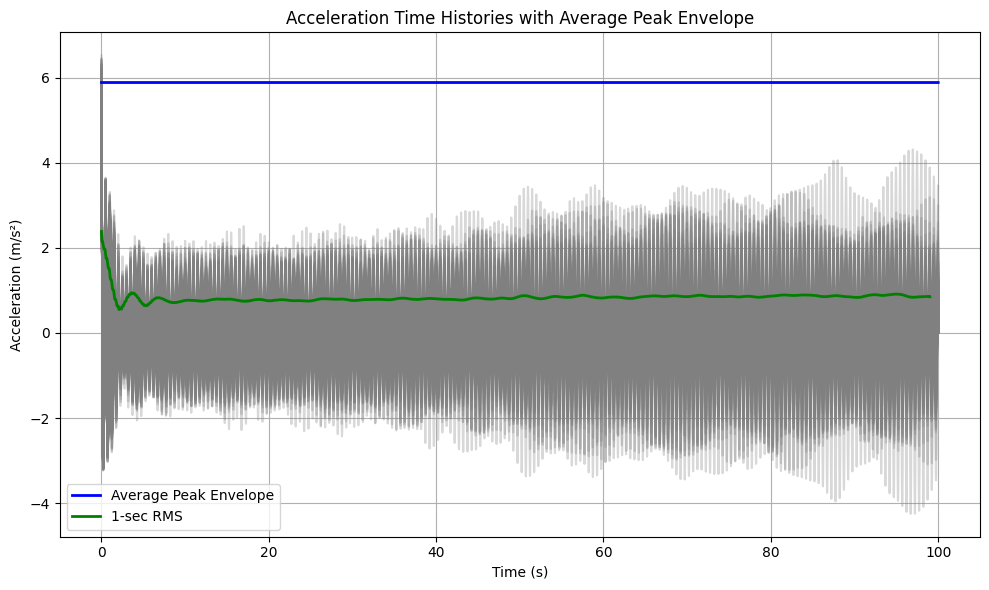

In [86]:
# --------------------------------------------------
# Time vector for acceleration
# --------------------------------------------------
time = np.arange(accelerations.shape[1]) * hht

# --------------------------------------------------
# Peak envelope for each simulation
# --------------------------------------------------
peak_env = np.zeros_like(accelerations)

for i in range(NUM_SIMULATIONS):
    peak_env[i] = np.maximum.accumulate(np.abs(accelerations[i]))

# Average peak envelope
mean_peak_env = np.mean(peak_env, axis=0)

# --------------------------------------------------
# 1-second RMS
# --------------------------------------------------
window = int(1 / hht)

rms_results = []
for i in range(NUM_SIMULATIONS):
    acc = accelerations[i]
    rms = np.sqrt(np.convolve(acc**2, np.ones(window) / window, mode='valid'))
    rms_results.append(rms)

rms_results = np.array(rms_results)

# Mean RMS across simulations
mean_rms = np.mean(rms_results, axis=0)

# Time vector for RMS ('valid' convolution shortens the length)
time_rms = np.arange(len(mean_rms)) * hht

# --------------------------------------------------
# Plot acceleration histories
# --------------------------------------------------
plt.figure(figsize=(10, 6))

# Individual acceleration histories
for i in range(NUM_SIMULATIONS):
    plt.plot(time, accelerations[i], color='gray', alpha=0.3)

# Mean acceleration
#plt.plot(time, mean_acceleration, color='red', linewidth=2, label='Mean Acceleration')

# Average peak envelope
plt.plot(time, mean_peak_env, color='blue', linewidth=2, label='Average Peak Envelope')

# 1-sec RMS
plt.plot(time_rms, mean_rms, color='green', linewidth=2, label='1-sec RMS')

plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s²)")
plt.title("Acceleration Time Histories with Average Peak Envelope")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

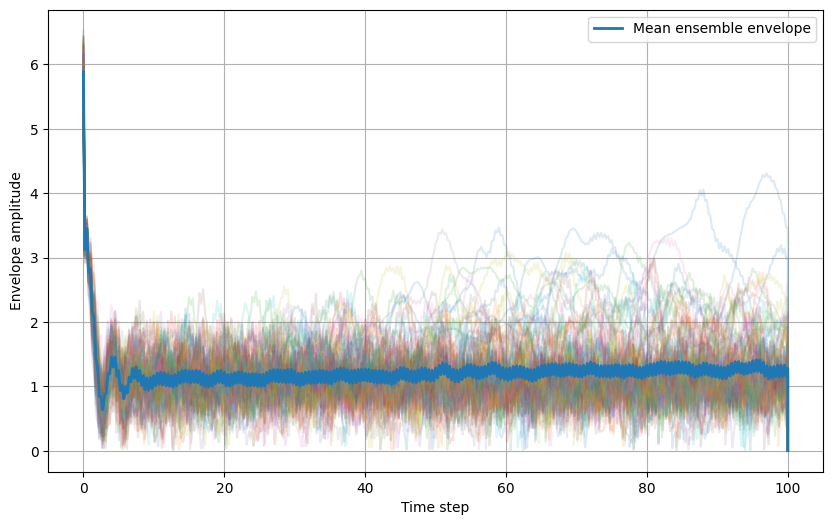

In [87]:
import numpy as np
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# accelerations shape = (NUM_SIMULATIONS, N)
NUM_SIMULATIONS, N = accelerations.shape
t = np.arange(N)

# store envelope of each simulation
envelopes = np.zeros_like(accelerations, dtype=float)

for i in range(NUM_SIMULATIONS):
    sig = accelerations[i]
    abs_sig = np.abs(sig)

    # find local peaks of absolute signal
    peaks, _ = find_peaks(abs_sig)

    # if too few peaks, fall back safely
    if len(peaks) < 2:
        envelopes[i] = abs_sig
        continue

    # include first and last points so interpolation spans full record
    x_env = np.concatenate(([0], peaks, [N - 1]))
    y_env = np.concatenate(([abs_sig[0]], abs_sig[peaks], [abs_sig[-1]]))

    # join peaks
    f_env = interp1d(x_env, y_env, kind='linear', fill_value='extrapolate')
    envelopes[i] = f_env(t)

# ensemble mean envelope
mean_envelope = np.mean(envelopes, axis=0)

# optional: ensemble standard deviation
std_envelope = np.std(envelopes, axis=0)

# plot
plt.figure(figsize=(10, 6))

# individual envelopes
for i in range(NUM_SIMULATIONS):
    plt.plot(t*0.01, envelopes[i], alpha=0.15)

# mean envelope
plt.plot(t*0.01, mean_envelope, linewidth=2, label='Mean ensemble envelope')

plt.xlabel('Time step')
plt.ylabel('Envelope amplitude')
plt.legend()
plt.grid(True)
plt.show()

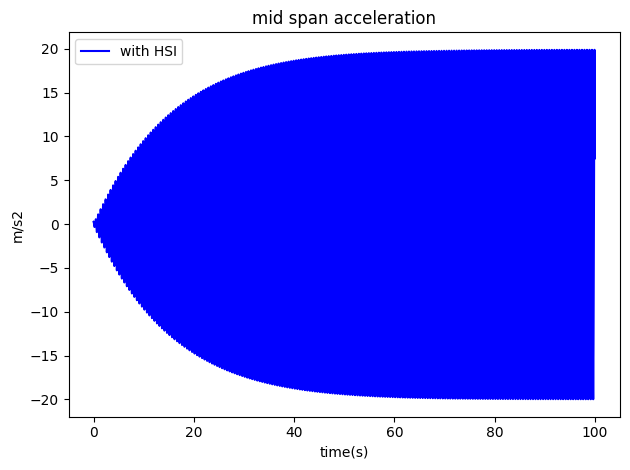

In [88]:
from matrix import*  
from solver import *
from pedestrian import* 
from matplotlib import pyplot as plt
import math
import numpy as np


#step 1 setup beam and pedestrians
#beam
numElements = 10  # n - Number of beam elements !not for modal
length = 50  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq = np.array([2,8])  #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2



numbers = 2 #modes bein considered
#modal_mass = 58000 #kg
#def curve1(x):
#    return -3.3245e-23 * x**0 + -1.4885e-02 * x**1 + 7.2714e-04 * x**2 + 1.2637e-04 * x**3 + -1.4437e-05 * x**4 + 7.2750e-07 * x**5 + -1.9644e-08 * x**6 + 3.0059e-10 * x**7 + -2.6205e-12 * x**8 + 1.2166e-14 * x**9 + -2.3396e-17 * x**10 + 9.6919e-29 * x**11

ModalMass = 1.28*linearMass*length/2


def curve1(x):
    return np.sin(np.pi*x/length)

def curve2(x):
    return np.sin(2*np.pi*x/length)

hht = 0.01
t_end = 100 
func_list=[curve1,curve2] 
modalmass = [ModalMass,ModalMass]
modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12


Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = numbers,
    freq = beamFreq,
      )                   #modes


         
density = 1.0

t, u, du, ddu = Newmarksuper_Code(
    Bridge,
    numbers,
    length,
    hht,
    t_end,
    width,
    beamFreq,        # walking frequency fs
    density,            # density ped/m²
    modalDampingRatio,
    density*length*width,
    length * width, # deck area S
    modalmass,
    func_list
)
accn_hsi = accdyn_super_social(Bridge,ddu ,x_interested,modalmass,func_list)
#vertical_displacement = accdyn_super(Bridge,u,25,hht)


plt.plot(t,accn_hsi,label ="with HSI",color='b')
plt.title("mid span acceleration")
plt.xlabel("time(s)")
plt.ylabel("m/s2")
plt.legend()
plt.tight_layout()
#plt.savefig("All In one", format='pdf', dpi=300)  
plt.show()
#print("ddu",ddu)
#print("accn",accn)'''

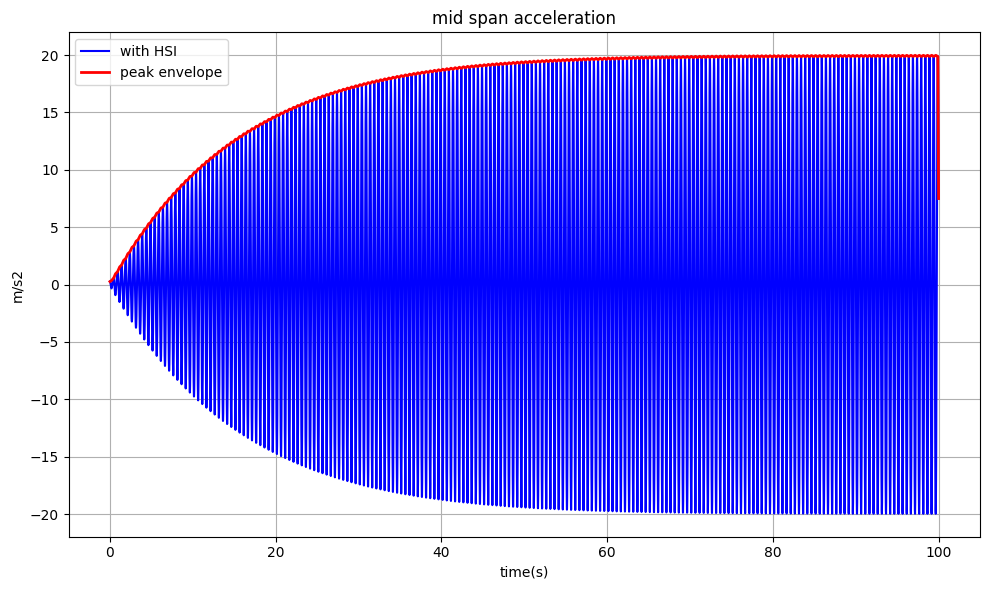

In [89]:
import numpy as np
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# single signal
sig = accn_hsi
abs_sig = np.abs(sig)

# time vector already exists from Newmark
# t = ...

# find peaks of absolute signal
peaks, _ = find_peaks(abs_sig)

# build envelope
if len(peaks) < 2:
    envelope = abs_sig
else:
    x_env = np.concatenate(([t[0]], t[peaks], [t[-1]]))
    y_env = np.concatenate(([abs_sig[0]], abs_sig[peaks], [abs_sig[-1]]))

    f_env = interp1d(x_env, y_env, kind='linear', fill_value='extrapolate')
    envelope = f_env(t)

# plot
plt.figure(figsize=(10, 6))
plt.plot(t, accn_hsi, label='with HSI', color='b')
plt.plot(t, envelope, label='peak envelope', color='r', linewidth=2)
#plt.plot(t, -envelope, color='r', linestyle='--', linewidth=2, label='negative envelope')
plt.xlabel('time(s)')
plt.ylabel('m/s2')
plt.title('mid span acceleration')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
plt.show()

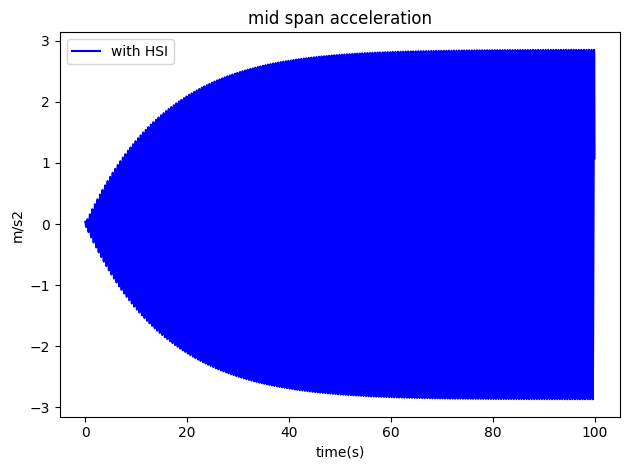

In [91]:
from matrix import*  
from solver import *
from pedestrian import* 
from matplotlib import pyplot as plt
import math
import numpy as np


#step 1 setup beam and pedestrians
#beam
numElements = 10  # n - Number of beam elements !not for modal
length = 50  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005# xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq = np.array([2.00,8])  #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2



numbers = 2 #modes bein considered
#modal_mass = 58000 #kg
#def curve1(x):
#    return -3.3245e-23 * x**0 + -1.4885e-02 * x**1 + 7.2714e-04 * x**2 + 1.2637e-04 * x**3 + -1.4437e-05 * x**4 + 7.2750e-07 * x**5 + -1.9644e-08 * x**6 + 3.0059e-10 * x**7 + -2.6205e-12 * x**8 + 1.2166e-14 * x**9 + -2.3396e-17 * x**10 + 9.6919e-29 * x**11

ModalMass = 1.28*linearMass*length/2 *1.15


def curve1(x):
    return np.sin(np.pi*x/length)

def curve2(x):
    return np.sin(2*np.pi*x/length)

hht = 0.01
t_end = 100 
func_list=[curve1,curve2] 
modalmass = [ModalMass,ModalMass]
modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12


Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = numbers,
    freq = beamFreq,
      )                   #modes


         
density = 1.0/ 6.25

t, u, du, ddu1 = Newmarksuper_Code(
    Bridge,
    numbers,
    length,
    hht,
    t_end,
    width,
    beamFreq,        # walking frequency fs
    density,            # density ped/m²
    modalDampingRatio,
    density*length*width,
    length * width, # deck area S
    modalmass,
    func_list
)
accn_hsi_simplified1 = accdyn_super_social(Bridge,ddu1 ,x_interested,modalmass,func_list)
#vertical_displacement = accdyn_super(Bridge,u,25,hht)


plt.plot(t,accn_hsi_simplified1,label ="with HSI",color='b')
plt.title("mid span acceleration")
plt.xlabel("time(s)")
plt.ylabel("m/s2")
plt.legend()
plt.tight_layout()
#plt.savefig("All In one", format='pdf', dpi=300)  
plt.show()
#print("ddu",ddu)
#print("accn",accn)'''

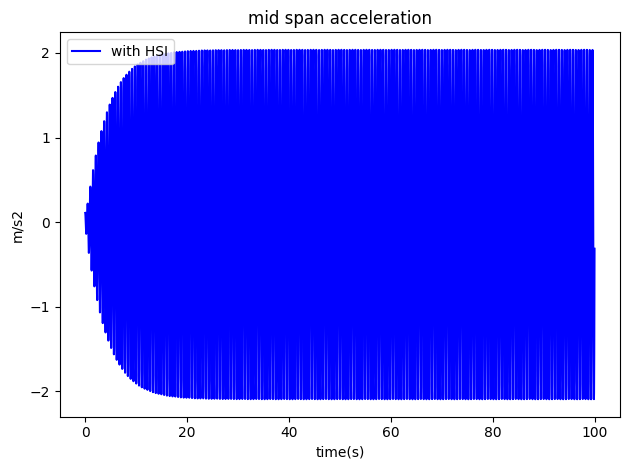

In [79]:
from matrix import*  
from solver import *
from pedestrian import* 
from matplotlib import pyplot as plt
import math
import numpy as np


#step 1 setup beam and pedestrians
#beam
numElements = 10  # n - Number of beam elements !not for modal
length = 50  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.021# xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq = np.array([1.825,8])  #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2



numbers = 2 #modes bein considered
#modal_mass = 58000 #kg
#def curve1(x):
#    return -3.3245e-23 * x**0 + -1.4885e-02 * x**1 + 7.2714e-04 * x**2 + 1.2637e-04 * x**3 + -1.4437e-05 * x**4 + 7.2750e-07 * x**5 + -1.9644e-08 * x**6 + 3.0059e-10 * x**7 + -2.6205e-12 * x**8 + 1.2166e-14 * x**9 + -2.3396e-17 * x**10 + 9.6919e-29 * x**11

ModalMass = 1.15*linearMass*length/2


def curve1(x):
    return np.sin(np.pi*x/length)

def curve2(x):
    return np.sin(2*np.pi*x/length)

hht = 0.01
t_end = 100 
func_list=[curve1,curve2] 
modalmass = [ModalMass,ModalMass]
modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12


Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = numbers,
    freq = beamFreq,
      )                   #modes


         
density = 0.2

t, u, du, ddu2 = Newmarksuper_Code(
    Bridge,
    numbers,
    length,
    hht,
    t_end,
    width,
    beamFreq,        # walking frequency fs
    density,            # density ped/m²
    modalDampingRatio,
    density*length*width,
    length * width, # deck area S
    modalmass,
    func_list
)
accn_hsi_simplified2 = accdyn_super_social(Bridge,ddu2 ,x_interested,modalmass,func_list)
#vertical_displacement = accdyn_super(Bridge,u,25,hht)


plt.plot(t,accn_hsi_simplified2,label ="with HSI",color='b')
plt.title("mid span acceleration")
plt.xlabel("time(s)")
plt.ylabel("m/s2")
plt.legend()
plt.tight_layout()
#plt.savefig("All In one", format='pdf', dpi=300)  
plt.show()
#print("ddu",ddu)
#print("accn",accn)'''

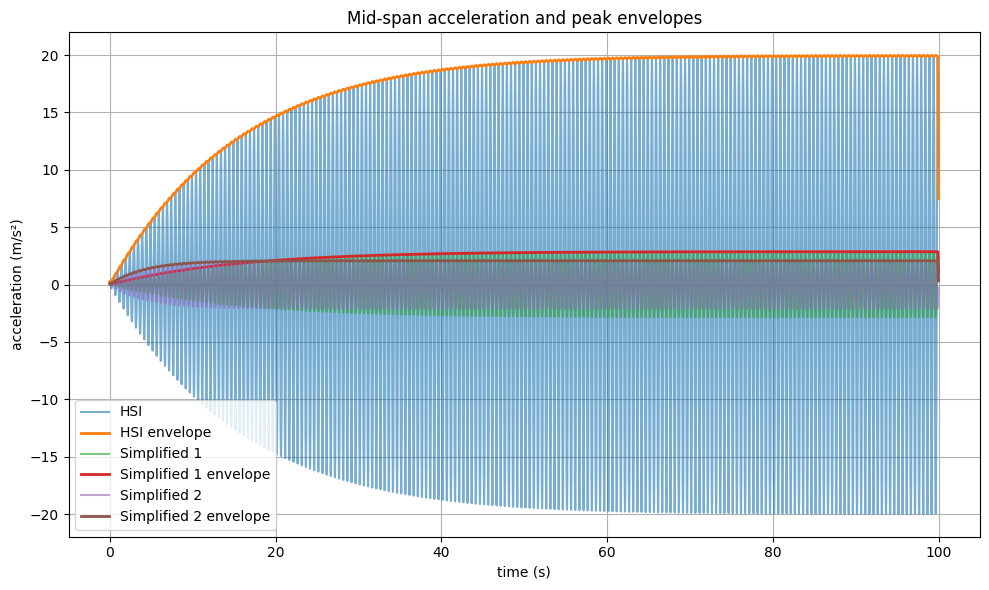

In [92]:
import numpy as np
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

def peak_envelope(sig, t):
    abs_sig = np.abs(sig)
    peaks, _ = find_peaks(abs_sig)

    if len(peaks) < 2:
        return abs_sig

    x_env = np.concatenate(([t[0]], t[peaks], [t[-1]]))
    y_env = np.concatenate(([abs_sig[0]], abs_sig[peaks], [abs_sig[-1]]))

    f_env = interp1d(x_env, y_env, kind='linear', fill_value='extrapolate')
    return f_env(t)

# envelopes
env_hsi = peak_envelope(accn_hsi, t)
env_s1 = peak_envelope(accn_hsi_simplified1, t)
env_s2 = peak_envelope(accn_hsi_simplified2, t)

# plot
plt.figure(figsize=(10, 6))

plt.plot(t, accn_hsi, label='HSI', alpha=0.6)
plt.plot(t, env_hsi, label='HSI envelope', linewidth=2)

plt.plot(t, accn_hsi_simplified1, label='Simplified 1', alpha=0.6)
plt.plot(t, env_s1, label='Simplified 1 envelope', linewidth=2)

plt.plot(t, accn_hsi_simplified2, label='Simplified 2', alpha=0.6)
plt.plot(t, env_s2, label='Simplified 2 envelope', linewidth=2)

plt.xlabel('time (s)')
plt.ylabel('acceleration (m/s²)')
plt.title('Mid-span acceleration and peak envelopes')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

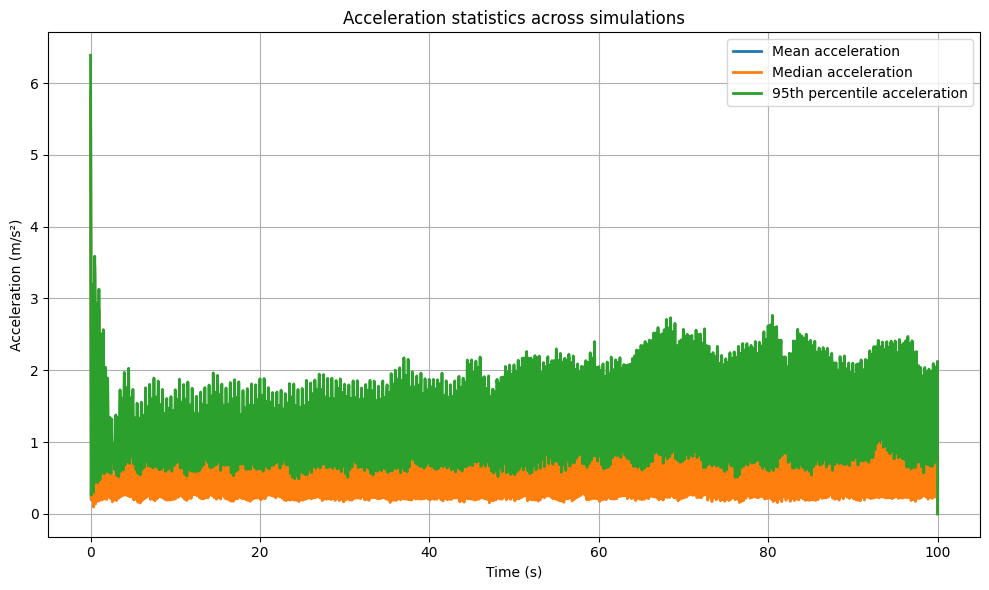

In [93]:
import numpy as np
import matplotlib.pyplot as plt

# accelerations shape = (NUM_SIMULATIONS, N)
NUM_SIMULATIONS, N = accelerations.shape
t = np.arange(N) * hht   # use your actual time step

# 95th percentile acceleration at each time step
acc_95 = np.percentile(abs(accelerations), 95, axis=0)

# optional: also get median and mean
acc_50 = np.percentile(abs(accelerations), 50, axis=0)
acc_mean = np.mean(abs(accelerations), axis=0)

# plot
plt.figure(figsize=(10, 6))
plt.plot(t, acc_mean, label='Mean acceleration', linewidth=2)
plt.plot(t, acc_50, label='Median acceleration', linewidth=2)
plt.plot(t, acc_95, label='95th percentile acceleration', linewidth=2)

plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s²)')
plt.title('Acceleration statistics across simulations')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

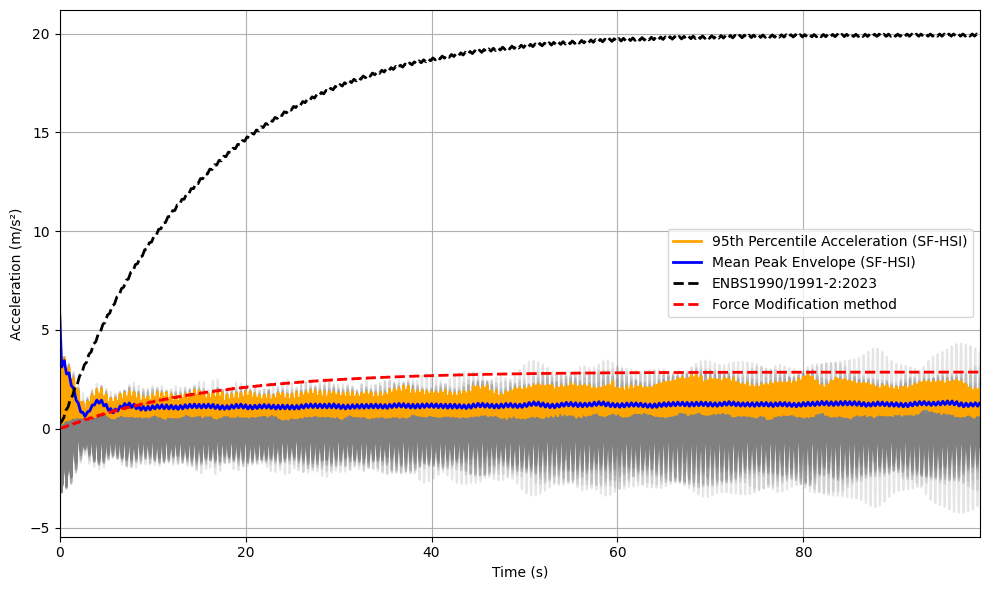

In [94]:
# -----------------------------
# TIME VECTORS
# -----------------------------
time = np.arange(accelerations.shape[1]) * hht

# -----------------------------
# MONTE CARLO PEAK ENVELOPE
# -----------------------------
peak_env = np.maximum.accumulate(np.abs(accelerations), axis=1)
mean_peak_env = np.mean(peak_env, axis=0)

# -----------------------------
# 1 SECOND RMS
# -----------------------------
window = int(1 / hht)

rms_results = []
for i in range(NUM_SIMULATIONS):
    acc = accelerations[i]
    rms = np.sqrt(np.convolve(acc**2, np.ones(window) / window, mode='valid'))
    rms_results.append(rms)

rms_results = np.array(rms_results)
mean_rms = np.mean(rms_results, axis=0)

time_rms = np.arange(len(mean_rms)) * hht

# -----------------------------
# UDL RESPONSE PEAK ENVELOPE
# -----------------------------
peak_env_udl = np.maximum.accumulate(np.abs(accn_hsi))
peak_env_udl2 = np.maximum.accumulate(np.abs(accn_hsi_simplified1))
peak_env_udl3 = np.maximum.accumulate(np.abs(accn_hsi_simplified2))

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(10, 6))

# Monte Carlo individual runs
for i in range(NUM_SIMULATIONS):
    plt.plot(time, accelerations[i], color='gray', alpha=0.2)

# Mean Monte Carlo response
#plt.plot(time, 0.1*mean_acceleration, color='red', linewidth=2,
#         label='Mean Acceleration (SF-HSI)')

# Mean Monte Carlo response
plt.plot(time, acc_95, color='orange', linewidth=2,
         label='95th Percentile Acceleration (SF-HSI)')

# Monte Carlo peak envelope
plt.plot(time, mean_envelope, color='blue', linewidth=2,
         label='Mean Peak Envelope (SF-HSI)')

# 1-sec RMS
#plt.plot(time_rms, mean_rms, color='green', linewidth=2,
#         label='1-sec RMS (SF-HSI)')

# UDL peak envelope
plt.plot(t, envelope, color='black', linestyle='--', linewidth=2,
         label='ENBS1990/1991-2:2023')

# UDL peak envelope
#plt.plot(t, envelope/ 5, color='green', linestyle='--', linewidth=2,
#         label='response modifier')

plt.plot(t, peak_env_udl2, color='red', linestyle='--', linewidth=2,
         label='Force Modification method')
#plt.plot(t, peak_env_udl3, color='purple', linestyle='--', linewidth=2,
#         label='Stiffness and damping modification method')

plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s²)")
plt.xlim(0,99)
# plt.title("Monte Carlo HSI vs UDL Response")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()